In [5]:
import numpy as np
from scipy.optimize import minimize_scalar

data = np.array([
    [1, 1.09, 1.08, 1.34],
    [1, 1.16, 1.26, 1.54],
    [1, 1.22, 1.07, 1.03],
    [1, 0.93, 0.97, 0.92],
    [1, 1.11, 1.56, 1.52],
    [1, 0.76, 0.77, 0.90],
    [1, 0.92, 0.84, 1.01],
    [1, 0.88, 1.22, 1.34]
])

r = 0.06
xi = np.log(data[:, 1:] / data[:, :-1]).flatten()  # 24 log-returns
M = len(xi)

# --- sigma_RV ---
sigma_RV = np.std(xi, ddof=1)
se_RV = sigma_RV / np.sqrt(2 * (M - 1))

# --- sigma_MLE ---
def neg_ll(sigma):
    mu = r - 0.5 * sigma**2
    return 0.5 * M * np.log(2 * np.pi) + M * np.log(sigma) + \
           0.5 * np.sum((xi - mu)**2) / sigma**2

result = minimize_scalar(neg_ll, bounds=(0.01, 2.0), method='bounded')
sigma_ML = result.x
def d2_log_ll(sigma):
    u = xi - r  # xi_k - r, shape (24,)
    M = len(xi)
    
    d2 = (M / sigma**2 
          - 3 * np.sum(u**2) / sigma**4 
          - M / 4)
    return d2

se_ML = np.sqrt(-1 / d2_log_ll(sigma_ML))
print(f"sigma_ML: {sigma_ML:.4f},  SE: {se_ML:.3f}")
print(f"sigma_RV: {sigma_RV:.4f},  SE: {se_RV:.3f}")

sigma_ML: 0.1484,  SE: 0.021
sigma_RV: 0.1519,  SE: 0.022


In [6]:
from scipy.stats import norm

def bs_put(S, K, sd, T, r):
    d1 = (np.log(S/K) + (r + 0.5*sd**2)*T) / (sd*np.sqrt(T))
    d2 = d1 - sd*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bermudan_put_tree(S0, K, r, sd, T, exercise_times, N=1000):
    """Binomial tree for Bermudan put, exercise only at specified times."""
    dt = T / N
    u = np.exp(sd * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    df = np.exp(-r * dt)

    # Terminal stock prices
    j = np.arange(N + 1)
    S = S0 * u**j * d**(N - j)
    V = np.maximum(K - S, 0)

    exercise_steps = set(round(t / dt) for t in exercise_times)

    for i in range(N - 1, -1, -1):
        S = S0 * u**np.arange(i + 1) * d**(i - np.arange(i + 1))
        V = df * (p * V[1:i+2] + (1-p) * V[0:i+1])
        if i in exercise_steps:
            V = np.maximum(V, np.maximum(K - S, 0))
    return V[0]

def american_put_tree(S0, K, r, sd, T, N=1000):
    """Binomial tree for American put."""
    dt = T / N
    u = np.exp(sd * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    df = np.exp(-r * dt)

    j = np.arange(N + 1)
    S = S0 * u**j * d**(N - j)
    V = np.maximum(K - S, 0)

    for i in range(N - 1, -1, -1):
        S = S0 * u**np.arange(i+1) * d**(i - np.arange(i+1))
        V = df * (p * V[1:i+2] + (1-p) * V[0:i+1])
        V = np.maximum(V, np.maximum(K - S, 0))
    return V[0]

S0, K, r, T = 1, 1.1, 0.06, 3

for sigma in [0.1484, 0.1500, 0.1519]:
    euro    = bs_put(S0, K, sigma, T, r)
    berm    = bermudan_put_tree(S0, K, r, sigma, T, exercise_times=[1,2,3])
    amer    = american_put_tree(S0, K, r, sigma, T)
    print(f"σ={sigma:.4f}  American={amer:.4f}  Bermudan={berm:.4f}  European={euro:.4f}")

σ=0.1484  American=0.1085  Bermudan=0.0917  European=0.0628
σ=0.1500  American=0.1092  Bermudan=0.0926  European=0.0637
σ=0.1519  American=0.1100  Bermudan=0.0937  European=0.0649


In [7]:
def LSM_poly(S, K, r, degree):
    """LSM on the fixed LS example paths with given polynomial degree."""
    M = S.shape[1] - 1
    dt = 1.0
    df = np.exp(-r * dt)

    h = np.maximum(K - S, 0)
    h[:, 0] = 0
    cashflow = h.copy()

    for t in range(M - 1, 0, -1):
        ITM = h[:, t] > 0
        if ITM.sum() == 0:
            continue

        Y = df * cashflow[ITM, t + 1]
        X = S[ITM, t]

        # Polynomial basis of given degree
        Z = np.column_stack([X**d for d in range(degree + 1)])

        # Matrix OLS: (X'X)^{-1} X'y
        b = np.linalg.lstsq(Z, Y, rcond=None)[0]

        Z_all = np.column_stack([S[:, t]**d for d in range(degree + 1)])
        cont = Z_all @ b

        exercise = (h[:, t] > cont) & (h[:, t] > 0)
        cashflow[exercise, t] = h[exercise, t]
        cashflow[exercise, t+1:] = 0
        cashflow[~exercise & ITM, t] = 0

    disc = np.array([df**t for t in range(M + 1)])
    price = np.mean(cashflow @ disc) 
    return price

S = np.array([
    [1, 1.09, 1.08, 1.34],
    [1, 1.16, 1.26, 1.54],
    [1, 1.22, 1.07, 1.03],
    [1, 0.93, 0.97, 0.92],
    [1, 1.11, 1.56, 1.52],
    [1, 0.76, 0.77, 0.90],
    [1, 0.92, 0.84, 1.01],
    [1, 0.88, 1.22, 1.34]
])

for deg in [2, 3, 4, 5]:
    print(f"Degree {deg}: {LSM_poly(S, 1.1, 0.06, deg):.6f}")

Degree 2: 0.114434
Degree 3: 0.116652
Degree 4: 0.124287
Degree 5: 0.124287


Mean:          0.1426
Std deviation: 0.0631
True Bermudan: 0.0926
Bias:          0.0500


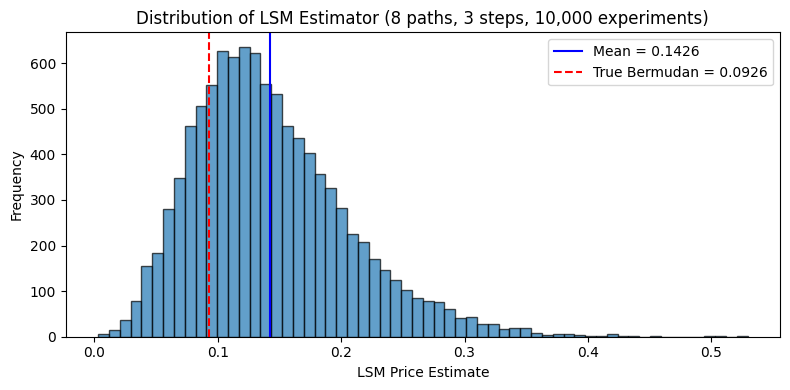

In [13]:
def LSM_single(K, r, sigma, T, steps, paths, degree=2):
    dt = T / steps
    df = np.exp(-r * dt)
    S = np.zeros((paths, steps + 1))
    S[:, 0] = 1.0
    for t in range(1, steps + 1):
        Z = np.random.normal(0, 1, paths)
        S[:, t] = S[:, t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

    h = np.maximum(K - S, 0)
    h[:, 0] = 0
    cashflow = h.copy()

    for t in range(steps - 1, 0, -1):
        ITM = h[:, t] > 0
        if ITM.sum() < degree + 1:
            continue
        Y = df * cashflow[ITM, t + 1]
        X = S[ITM, t]
        Z_mat = np.column_stack([X**d for d in range(degree + 1)])
        b = np.linalg.lstsq(Z_mat, Y, rcond=None)[0]
        Z_all = np.column_stack([S[:, t]**d for d in range(degree + 1)])
        cont = Z_all @ b
        exercise = (h[:, t] > cont) & (h[:, t] > 0)
        cashflow[exercise, t] = h[exercise, t]
        cashflow[exercise, t+1:] = 0

    disc = np.array([df**t for t in range(steps + 1)])
    return np.mean(cashflow @ disc)

np.random.seed(42)
N_exp = 10000
estimates = [LSM_single(K=1.1, r=0.06, sigma=0.15, T=3, steps=3, paths=8) 
             for _ in range(N_exp)]

estimates = np.array(estimates)
true_berm = 0.0926  # from Table 2

print(f"Mean:          {estimates.mean():.4f}")
print(f"Std deviation: {estimates.std():.4f}")
print(f"True Bermudan: {true_berm:.4f}")
print(f"Bias:          {estimates.mean() - true_berm:.4f}")


import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.hist(estimates, bins=60, edgecolor='black', alpha=0.7)
plt.axvline(estimates.mean(), color='blue', label=f'Mean = {estimates.mean():.4f}')
plt.axvline(true_berm, color='red', linestyle='--', label=f'True Bermudan = {true_berm}')
plt.xlabel('LSM Price Estimate')
plt.ylabel('Frequency')
plt.title('Distribution of LSM Estimator (8 paths, 3 steps, 10,000 experiments)')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Step 1: Extract B from the original LS example
def get_LSM_coefficients(S, K, r, degree=2):
    M = S.shape[1] - 1
    dt = 1.0
    df = np.exp(-r * dt)
    h = np.maximum(K - S, 0)
    h[:, 0] = 0
    cashflow = h.copy()
    B = {}

    for t in range(M - 1, 0, -1):
        ITM = h[:, t] > 0
        Y = df * cashflow[ITM, t + 1]
        X = S[ITM, t]
        Z = np.column_stack([X**d for d in range(degree + 1)])
        b = np.linalg.lstsq(Z, Y, rcond=None)[0]
        B[t] = b
        Z_all = np.column_stack([S[:, t]**d for d in range(degree + 1)])
        cont = Z_all @ b
        exercise = (h[:, t] > cont) & (h[:, t] > 0)
        cashflow[exercise, t] = h[exercise, t]
        cashflow[exercise, t+1:] = 0

    return B

B = get_LSM_coefficients(S, K=1.1, r=0.06)

# Step 2: Apply fixed B to new simulated paths
def apply_fixed_strategy(B, K, r, sigma, T, steps, paths, degree=2):
    dt = T / steps
    df = np.exp(-r * dt)
    S_new = np.zeros((paths, steps + 1))
    S_new[:, 0] = 1.0
    for t in range(1, steps + 1):
        Z = np.random.normal(0, 1, paths)
        S_new[:, t] = S_new[:, t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

    h = np.maximum(K - S_new, 0)
    cashflow = h.copy()
    cashflow[:, 0] = 0

    for t in range(steps - 1, 0, -1):
        if t not in B:
            continue
        b = B[t]
        Z_all = np.column_stack([S_new[:, t]**d for d in range(degree + 1)])
        cont = Z_all @ b
        exercise = (h[:, t] > cont) & (h[:, t] > 0)
        cashflow[exercise, t] = h[exercise, t]
        cashflow[exercise, t+1:] = 0

    disc = np.array([df**t for t in range(steps + 1)])
    return np.mean(cashflow @ disc)

np.random.seed(42)
fixed_strategy_prices = [apply_fixed_strategy(B, K=1.1, r=0.06, sigma=0.15, 
                                               T=3, steps=3, paths=10000)
                         for _ in range(100)]

print(f"Expected payoff (fixed B): {np.mean(fixed_strategy_prices):.4f}")
print(f"True Bermudan price:       {true_berm:.4f}")

Expected payoff (fixed B): 0.0965
True Bermudan price:       0.0926
